# Chapter 8: Neural Networks
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from matplotlib.patches import Circle
from sklearn.preprocessing import MinMaxScaler
import keras
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import random
import shap

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../data')


/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Neural Networks
### Fitting a Network to Data
#### Activation Functions in the Hidden Layers

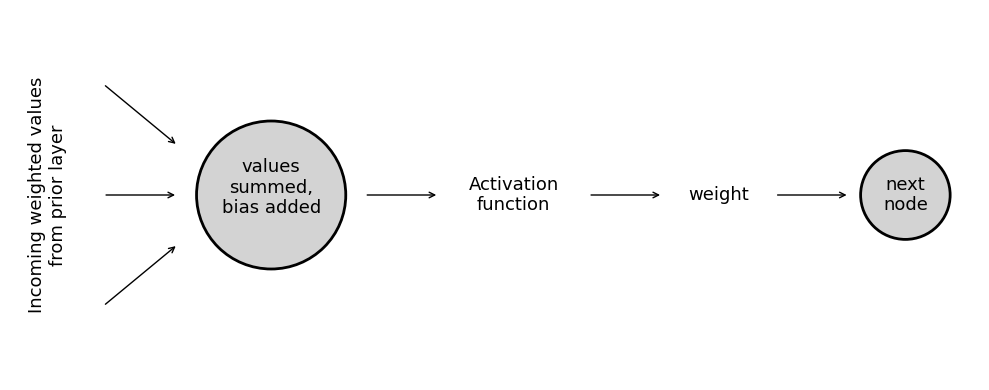

In [1]:
fig, ax = plt.subplots(figsize=(10, 4))

top = 100
fontsize = 13

xc = 10; yc = top / 2
ax.text(xc, yc, "Incoming weighted values\nfrom prior layer", fontsize=fontsize,
        va="center", ha="center", rotation=90)

xc = 70; yc = top / 2
circle = Circle((xc, yc), 20, color="lightgrey", ec="black", lw=2)
ax.add_artist(circle)

xl = 25; xr = 45
y1 = 0.8; y2 = 0.5; y3 = 0.2
f = (xr - xl) / (xc - xl)
for y in [y1, y2, y3]:
    ax.annotate("", xytext=(xl, y * top),
                xy=(xr, top * (f * (y - 0.5) + 0.5)),
                arrowprops={"arrowstyle": "->"})
ax.text(xc, yc + 2, "values\nsummed,\nbias added", fontsize=fontsize,
        va="center", ha="center")
xl = xc + (xc - xr); xr = xl + 20
ax.annotate("", xytext=(xl, yc), xy=(xr, yc),
            arrowprops={"arrowstyle": "->"})
ax.text(xr + 20, yc, "Activation\nfunction", fontsize=fontsize,
        va="center", ha="center")
xl = xr + 40; xr = xl + 20
ax.annotate("", xytext=(xl, yc), xy=(xr, yc),
            arrowprops={"arrowstyle": "->"})
ax.text(xr + 15, yc, "weight", fontsize=fontsize,
        va="center", ha="center")
xl = xr + 30; xr = xl + 20
ax.annotate("", xytext=(xl, yc), xy=(xr, yc),
            arrowprops={"arrowstyle": "->"})
xc = xr + 15
circle = Circle((xc, yc), 12, color="lightgrey", ec="black", lw=2)
ax.add_artist(circle)
ax.text(xc, yc, "next\nnode", fontsize=fontsize,
        va="center", ha="center")
ax.set_xlim(0, 2.6 * top)
ax.set_ylim(0, top)
ax.set_axis_off()

plt.tight_layout()
plt.show()

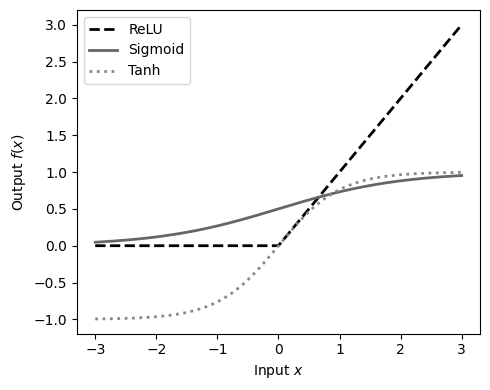

In [1]:
x = np.linspace(-3, 3, 200)
data = pd.DataFrame({
    "Input(x)": x,
    "ReLU": np.maximum(0, x),
    "Sigmoid": 1 / (1 + np.exp(-x)),
    "Tanh": np.tanh(x),
})
fig, ax = plt.subplots(figsize=[5, 4])
data.plot(x="Input(x)", y="ReLU", c="#000000", ax=ax, linestyle="--",
    linewidth=2)
data.plot(x="Input(x)", y="Sigmoid", c="#666666", ax=ax, linestyle="-",
    linewidth=2)
data.plot(x="Input(x)", y="Tanh", c="#888888", ax=ax, linestyle=":",
    linewidth=2)
ax.set_xlabel("Input $x$")
ax.set_ylabel("Output $f(x)$")

plt.tight_layout()

plt.tight_layout()
plt.show()

#### A Simple Model

In [1]:
# Read and prepare data
loan_data = (pd.read_csv(DATA_DIR / "loan_data.csv.gz", index_col=0)
             .drop("status", axis=1))

# Convert to numeric ordinal
for col in ["term", "emp_len_", "home_", "purpose_"]:
    loan_data[col] = pd.Categorical(loan_data[col]).codes

# Convert outcome to numeric
loan_data["outcome"] = pd.Categorical(loan_data["outcome"],
                                      categories=["paid off", "default"],
                                      ordered=True).codes

# Define predictors
all_predictors = ["loan_amnt", "term", "annual_inc", "dti",
                  "payment_inc_ratio", "revol_bal", "revol_util",
                  "delinq_2yrs_zero", "pub_rec_zero", "open_acc",
                  "home_", "purpose_", "grade", "emp_len_",
                  "borrower_score"]

# Scale using MinMaxScaler
loan_data_scaled = loan_data.copy()
scaler = MinMaxScaler()
loan_data_scaled[all_predictors] = scaler.fit_transform(
  loan_data_scaled[all_predictors])

# Create training matrices
train_x = loan_data_scaled[all_predictors]
train_y = loan_data["outcome"]

In [1]:
# Build the neural network
model = keras.Sequential([
    keras.layers.InputLayer(shape=(4,)),    # Input layer
    keras.layers.Dense(4, activation="relu"),     # First layer
    keras.layers.Dense(2, activation="relu"),     # Second layer
    keras.layers.Dense(1, activation="sigmoid"),  # Output layer
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Train the model with verbose output
history = model.fit(
    x=train_x[["payment_inc_ratio", "purpose_", "dti", "borrower_score"]],
    y=train_y,
    epochs=100,
    batch_size=128,
    verbose=0,
)

### Backpropagation and Gradient Descent
#### Overfitting

In [1]:
n = train_x.shape[0]
indices = np.random.permutation(n)
train_x = train_x.iloc[indices]
train_y = train_y.iloc[indices]

model = keras.Sequential([
    keras.layers.InputLayer(shape=(15,)),
    keras.layers.Dense(units=64, activation="relu"),
    keras.layers.Dense(units=32, activation="relu"),
    keras.layers.Dense(units=1, activation="sigmoid"),
])

model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.005),
    metrics=["accuracy"],
)

np.random.seed(42)
history = model.fit(
    x=train_x,
    y=train_y,
    epochs=500,
    batch_size=256,
    validation_split=0.1,
    verbose=0,
)

#### Regularization

In [1]:
reg_model = keras.Sequential([
    keras.layers.InputLayer(shape=(15,)),
    keras.layers.Dense(units=64, activation="relu",
              kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=32, activation="relu",
              kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=1, activation="sigmoid"),
])

reg_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.005),
    metrics=["accuracy"],
)


np.random.seed(42)
history_reg = reg_model.fit(
    x=train_x,
    y=train_y,
    epochs=500,
    batch_size=256,
    validation_split=0.1,
    verbose=0,
)

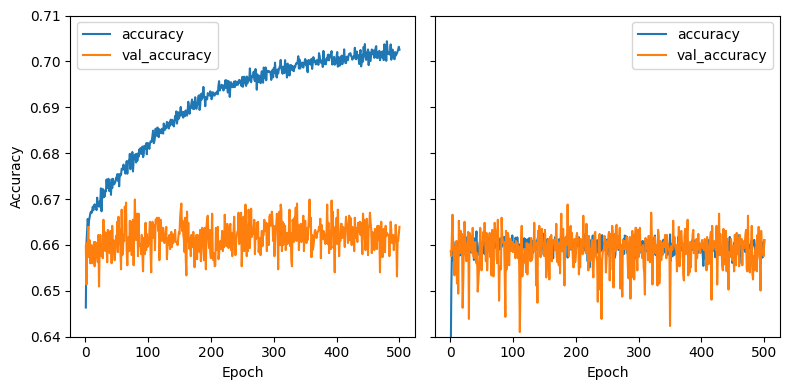

In [1]:
# Convert to DataFrames
history_df = pd.DataFrame({
    **history.history,
    "method": "simple",
    "epoch": range(1, 501),
})
history_reg_df = pd.DataFrame({
    **history_reg.history,
    "method": "regularized",
    "epoch": range(1, 501),
})
fig, axes = plt.subplots(ncols=2, figsize=(8, 4), sharey=True)
history_df.plot(x="epoch", y=["accuracy", "val_accuracy"], ax=axes[0])
history_reg_df.plot(x="epoch", y=["accuracy", "val_accuracy"], ax=axes[1])
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
axes[0].set_ylim(0.64, 0.71)
plt.tight_layout()

plt.tight_layout()
plt.show()

#### Interpretation and Variable Importance

In [1]:
ntrain = int(np.floor(0.9 * train_x.shape[0]))
shap_train = train_x.iloc[:ntrain, :].to_numpy()
shap_test = train_x.iloc[ntrain:ntrain + 100, :].to_numpy()

explainer = shap.DeepExplainer(
    model=reg_model,
    data=shap_train,  # Background data
)
shap_values = explainer.shap_values(
    shap_test,  # Data to explain
)

Background dataset has 40807 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=40807 when initializing the masker.


/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/shap/explainers/_deep/deep_tf.py:153: UserWarning: You have provided over 5k background samples! For better performance consider using smaller random sample.
  warnings.warn(
/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(40807, 15))']
  warnings.warn(msg)
/Users/petergedeck/cdd/practical-statistics-for-data-scientis

/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(100, 15))']
  warnings.warn(msg)


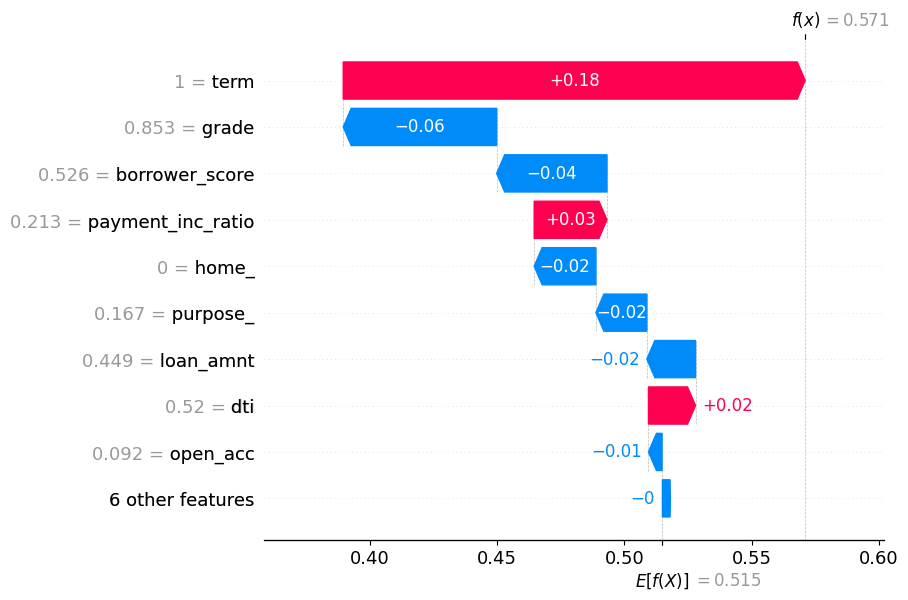

In [1]:
n = 3
shap.waterfall_plot(shap.Explanation(
    values=shap_values.squeeze()[n],
    base_values=float(explainer.expected_value[0]),
    data=shap_test[n, :],
    feature_names=all_predictors))

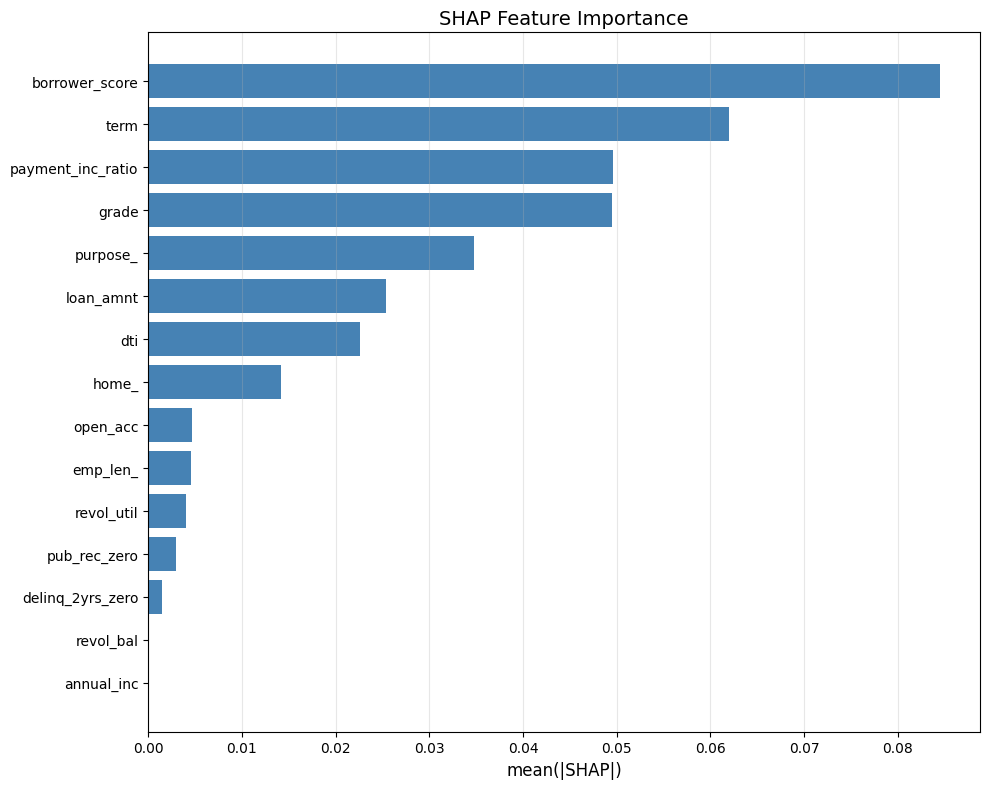

In [1]:
# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0).flatten()
# Sort by importance
sorted_idx = np.argsort(mean_abs_shap)
sorted_features = [all_predictors[i] for i in sorted_idx]
sorted_importance = mean_abs_shap[sorted_idx]

# Create horizontal bar plot (like R)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_features)), sorted_importance, color="steelblue")
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel("mean(|SHAP|)", fontsize=12)
plt.title("SHAP Feature Importance", fontsize=14)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.tight_layout()
plt.show()

# Supplementary Material

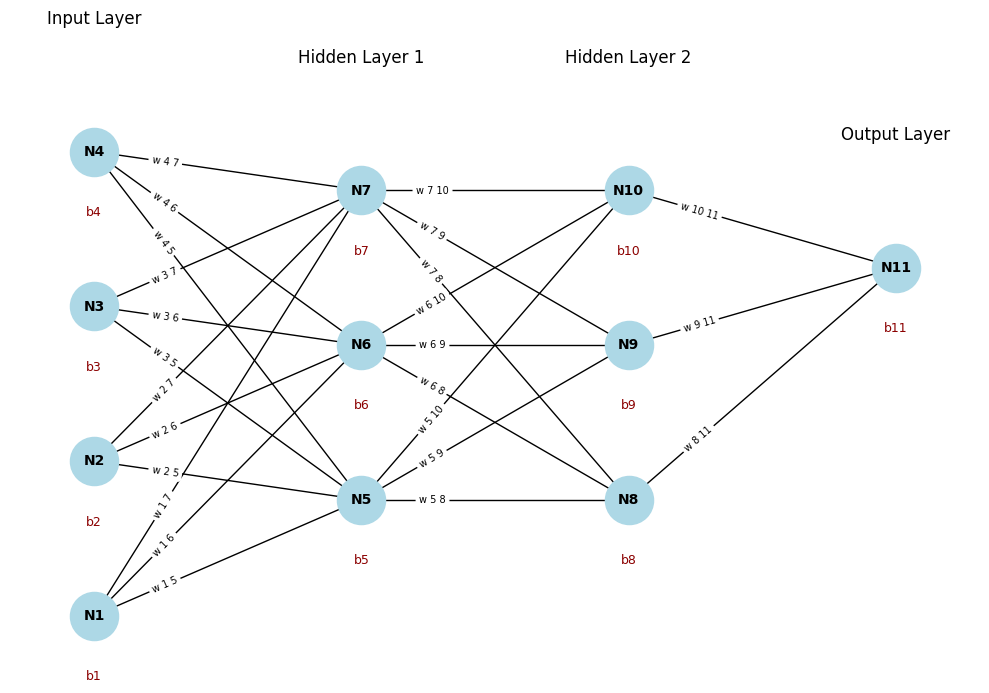

In [1]:
# PRODUCED BY CHAT-GPT

# Define the structure of the neural network
layers = [4, 3, 3, 1]  # Input layer, two hidden layers, output layer

# Create positions for nodes layer by layer
pos = {}
G = nx.DiGraph()
layer_dist = 2
node_dist = 1.5

node_counter = 1
node_ids = {}  # map (layer, j) -> global node id
for i, layer_size in enumerate(layers):
    for j in range(layer_size):
        node = (i, j)
        pos[node] = (i * layer_dist, j - (layer_size - 1) / 2 * node_dist)
        G.add_node(node)
        node_ids[node] = node_counter
        node_counter += 1

# Connect every node in one layer to every node in the next layer
for i in range(len(layers) - 1):
    for j in range(layers[i]):
        for k in range(layers[i + 1]):
            G.add_edge((i, j), (i + 1, k))

# Draw the network
plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=1200)
nx.draw_networkx_edges(G, pos, arrows=False)

# Add node labels (Ni)
labels = {node: f"N{node_ids[node]}" for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight="bold")

# Add bias labels under nodes
for node, (x, y) in pos.items():
    plt.text(x, y - 0.35, f"b{node_ids[node]}", fontsize=9, ha="center", va="top", color="darkred")

# Add weight labels to edges (with spaces, shifted left)
edge_labels = {}
for (u, v) in G.edges():
    i = node_ids[u]
    j = node_ids[v]
    edge_labels[(u, v)] = f"w {i} {j}"
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, label_pos=0.25)

# Add labels at the top of each layer
layer_names = ["Input Layer", "Hidden Layer 1", "Hidden Layer 2", "Output Layer"]
for i, name in enumerate(layer_names):
    x = i * layer_dist
    y = max(p[1] for n, p in pos.items() if n[0] == i) + 0.8
    plt.text(x, y, name, fontsize=12, ha="center", va="bottom")

plt.axis("off")

# Save as high-resolution PNG

plt.tight_layout()
plt.show()

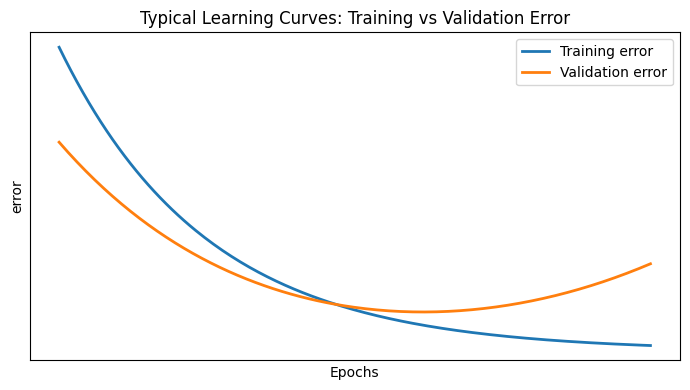

In [1]:
# Epochs from 0 to 1 (normalized training time)
epochs = np.linspace(0, 1, 200)

# Training error: smooth monotone decline
train_error = 0.8 * np.exp(-4 * epochs) + 0.05

# Validation error: declines, then rises (overfitting)
val_error = 0.6 * np.exp(-3 * epochs) + 0.25 * (epochs ** 3)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_error, linewidth=2, label="Training error")
plt.plot(epochs, val_error, linewidth=2, label="Validation error")

plt.xlabel("Epochs")
plt.ylabel("error")
plt.title("Typical Learning Curves: Training vs Validation Error")

plt.grid(visible=True)
plt.legend()

# Remove numeric tick labels on both axes
plt.xticks([])
plt.yticks([])

plt.tight_layout()

# If you want to save instead of just show:
plt.show()